<font color='green'> <br>
    ***********************************************************************************************  <br><br>
    &emsp; Deep Learning Project:&emsp; drone-vision-transformer <br><br>
    &emsp; Author:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp; Uttara Naidu <br><br>
    &emsp; Date:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 21/04/2026 <br><br>
    &emsp; Version: &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;v0.3 (WIP) <br><br>
    &emsp; Description:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Builds a multimodal ViT backbone and actor–critic RL heads for vision-based drone control experiments on the UZH-FPV dataset. <br><br>
    ***********************************************************************************************  <br>
 </font>

<font color='blue'> NOTE: This is a work-in-progress. Code clean-up, documentation and further updates will follow soon. </font>

The dataset is downloaded from: https://fpv.ifi.uzh.ch/datasets/

*Indoor forward facing:* 

Rogbag file: indoor_forward_5_snapdragon_with_gt.bag


In [1]:
from rosbags.highlevel import AnyReader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys, warnings

bag_path = Path('/Users/uni/data_files/fpv/indoor_forward_5_snapdragon_with_gt.bag')                # Path to downloaded .bag file
PROJ_DIR = '/Users/uni/dl_project_workspace/drone-vision-transformer'
DATA_DIR =  f'{PROJ_DIR}/data'
sys.path.append('/Users/uni/dl_project_workspace/drone-vision-transformer/')

from scripts.data_loader import explore_data, extract_data
from scripts.data_preprocessing import ViTDataset
from scripts.multimodal_vit import MultiModalViT
from scripts.actor_critic import MultiModalViTActorCritic

explore_data(bag_path)

TOPIC                          | MSG TYPE                       | COUNT     
---------------------------------------------------------------------------
/groundtruth/odometry          | nav_msgs/msg/Odometry          | 9650      
/groundtruth/pose              | geometry_msgs/msg/PoseStamped  | 9650      
/snappy_cam/stereo_l           | sensor_msgs/msg/Image          | 4162      
/snappy_cam/stereo_r           | sensor_msgs/msg/Image          | 4162      
/snappy_imu                    | sensor_msgs/msg/Imu            | 75042     


In [2]:
data_dir = Path(f"{DATA_DIR}/images")
data_dir.mkdir(parents=True, exist_ok=True)

extract_data(bag_path,data_dir)

----------- NUMBER OF DATA POINTS -----------
Images:8324 | IMU:75042 | Odometry:9650 | Pose:9650
Dataset created with 8324 synchronized rows.
Saved 75042 IMU messages to imu_data.csv


In [3]:
import pandas as pd

data = pd.read_csv(f'{DATA_DIR}/drone_dataset.csv')
data.head()

,timestamp,cam_id,img_path,imu_start_ts,imu_end_ts,pos_x,pos_y,pos_z,ori_w,vel_x,vel_y,vel_z
0,1540821095628558395,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
1,1540821095628558395,1,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
2,1540821095661733604,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
3,1540821095661733604,1,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
4,1540821095694906448,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0


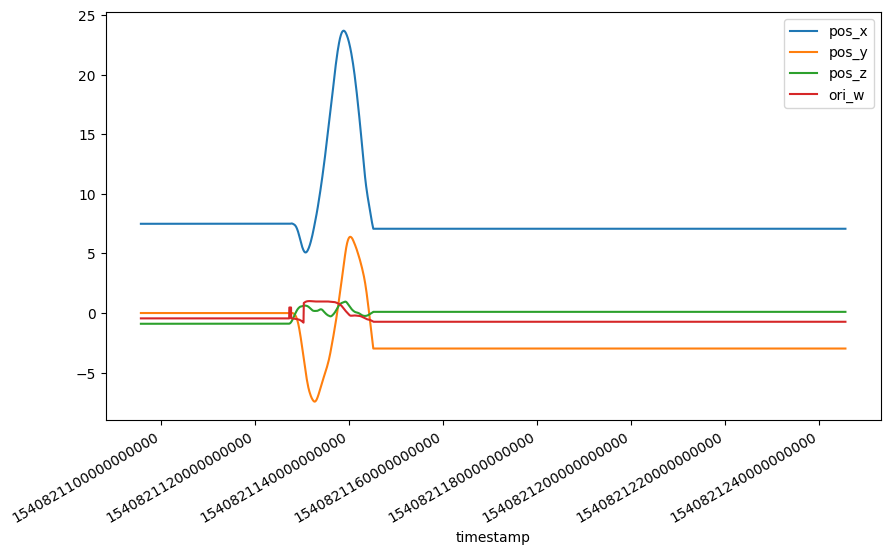

In [4]:
data.plot(x='timestamp',y=['pos_x','pos_y','pos_z','ori_w'],figsize=(10,6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.gcf().autofmt_xdate()

In [5]:
imu_df = pd.read_csv(f'{DATA_DIR}/imu_data.csv')
imu_df.head()

,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1540821095597876000,-0.124498,-0.220265,9.691679,-0.009587,-0.003196,-0.001065
1,1540821095599871000,-0.110133,-0.220265,9.706043,-0.006392,-0.004261,-0.002131
2,1540821095601871000,-0.124498,-0.186747,9.677314,-0.006392,-0.002131,-0.005326
3,1540821095603869000,-0.110133,-0.225054,9.725197,-0.004261,0.001065,-0.003196
4,1540821095605868000,-0.105344,-0.205900,9.753927,-0.001065,-0.003196,-0.002131


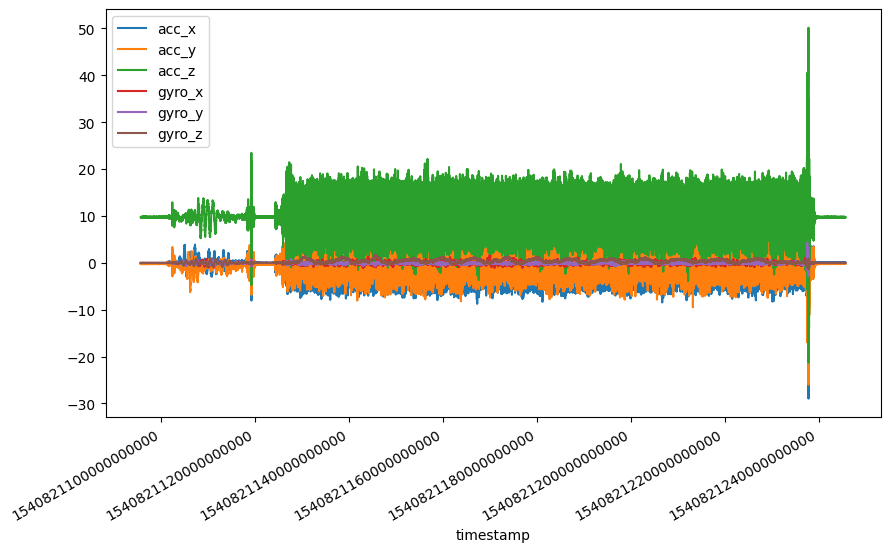

In [6]:
imu_df.plot(x='timestamp',figsize=(10,6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.gcf().autofmt_xdate()

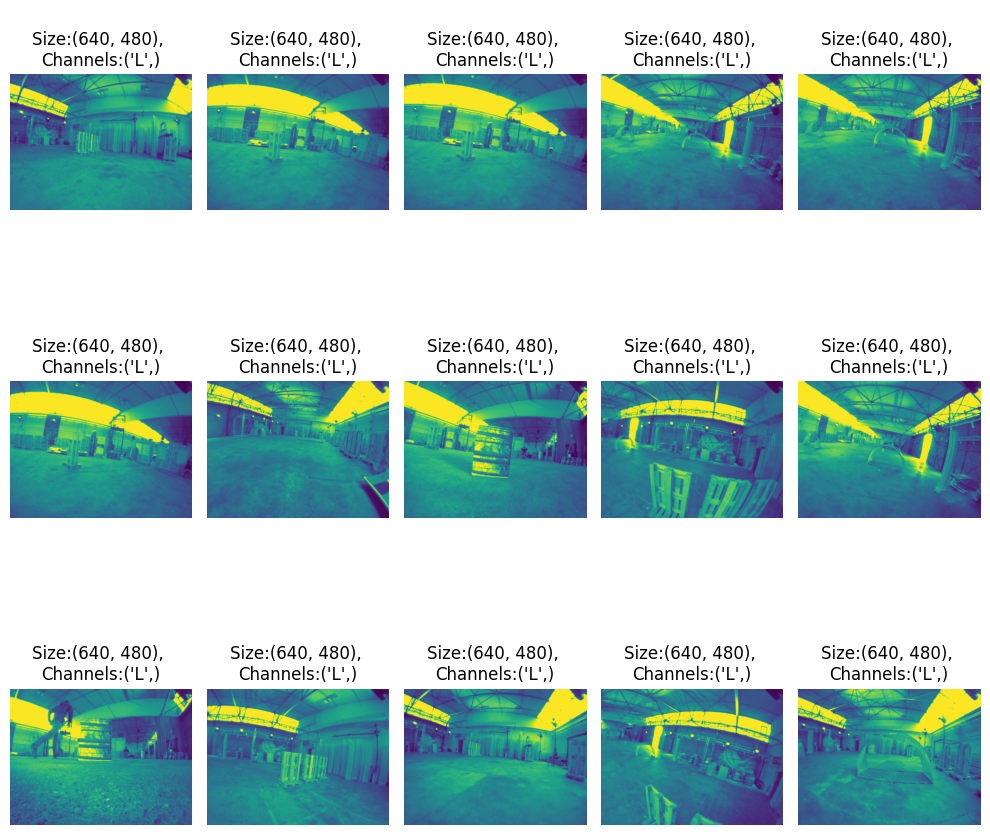

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import random

fig, ax = plt.subplots(3,5,figsize=(10,10))
axes_flat = ax.flatten()

random_idx = [random.randint(1,8000) for _ in range(15)]

for ax,idx in zip(axes_flat,random_idx):
    img = Image.open(data['img_path'][idx])
    ax.imshow(img)
    ax.set_title(f'\nSize:{img.size}, \nChannels:{img.getbands()}')
    ax.axis('off')

plt.tight_layout() 
plt.show()

In [8]:
import torch

# iMac-specific setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dataset = ViTDataset(f'{DATA_DIR}/drone_dataset.csv',f'{DATA_DIR}/imu_data.csv',DATA_DIR)

In [9]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset,batch_size=1,shuffle=True)
images, imu_sample,pos = next(iter(dataloader))
print('[INFO] Input tensor shape [B,C,H,W]: ',images.shape)
print('\n[INFO] IMU Window Statistics [Mean]: ')
print(f'\n Acceleration (x,y,z): ({imu_sample.tolist()[0][0]},{imu_sample.tolist()[0][1]},{imu_sample.tolist()[0][2]})')
print(f'\n Gyro (x,y,z): ({imu_sample.tolist()[0][3]},{imu_sample.tolist()[0][4]},{imu_sample.tolist()[0][5]})')
print(f'\n[INFO] Target pose (x,y,z):, {pos.tolist()}')

[INFO] Input tensor shape [B,C,H,W]:  torch.Size([1, 1, 256, 256])

[INFO] IMU Window Statistics [Mean]: 

 Acceleration (x,y,z): (-0.6997736692428589,-0.3475405275821686,9.278633117675781)

 Gyro (x,y,z): (0.006583334878087044,-0.008990832604467869,-0.06338323652744293)

[INFO] Target pose (x,y,z):, [[7.065465450286865, -2.9854683876037598, 0.09221266955137253]]


In [10]:
from torchinfo import summary

vit_encoder = MultiModalViT(img_size=(256,256))


model = MultiModalViTActorCritic(vit_encoder=vit_encoder,embed_dim=256,action_dim=4)            #action_dim: [thrust, roll_rate, pitch_rate, yaw_rate]
summary(model, [(1, 1, 256, 256),(1, 16, 6) ])

[INFO] Input tensor shape [B,C,H,W]:  torch.Size([1, 1, 256, 256])
[INFO] Extracting patches ...
[INFO] Number of patches:  256
[INFO] Number of heads:  8
[INFO] CLS feature shape:  torch.Size([1, 256])


Layer (type:depth-idx)                        Output Shape              Param #
MultiModalViTActorCritic                      [1, 4]                    --
├─MultiModalViT: 1-1                          --                        98,928
│    └─MultiModalEmbed: 2-1                   [1, 272, 256]             4,096
│    │    └─PatchEmbed: 3-1                   [1, 256, 256]             65,792
│    │    └─Linear: 3-2                       [1, 16, 256]              1,792
│    └─ModuleList: 2-2                        --                        --
│    │    └─TransformerEncoderBlock: 3-3      [1, 273, 256]             527,104
│    │    └─TransformerEncoderBlock: 3-4      [1, 273, 256]             527,104
│    │    └─TransformerEncoderBlock: 3-5      [1, 273, 256]             527,104
│    │    └─TransformerEncoderBlock: 3-6      [1, 273, 256]             527,104
│    │    └─TransformerEncoderBlock: 3-7      [1, 273, 256]             527,104
│    │    └─TransformerEncoderBlock: 3-8      [1, 273, 2